In [1]:
# VRFarm data-loading example.
# Each session is ONE consolidated <session_id>.h5 (format_version 2). analysis.loaders turns it
# into a small family of tidy pandas DataFrames — see docs/DATA_FORMAT.md for the full schema.
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.loaders import Session, Dataset

In [2]:
from pathlib import Path

# One session. A session directory OR the .h5 path inside it both work.
data_dir = Path("/Users/hakan/Library/CloudStorage/Dropbox/Hakan/lab/data/cheese_data/ASD110/ASD110_20260804/ASD110_20260804_001")
s = Session(data_dir)
s          # -> Session('ASD110_20260804_001', n_trials=50)

Session('ASD110_20260804_001', n_trials=50)

In [3]:
# A session exposes several DataFrames at different granularities. Each carries session_id /
# subject_id columns so sessions stack cleanly (see the Dataset cell at the end). Optional
# tables are empty when their device wasn't saved this session (here: no encoder -> running empty).
for name in ["trials", "running", "licks", "pulses", "stimulus", "camera"]:
    df = getattr(s, name)
    print(f"{name:9s} {str(df.shape):>10s}   {list(df.columns)}")

print("\nlevel:", s.meta.get("level"), "| saved devices:", s.meta.get("saved_devices"))
print("task_config sections:", list(s.meta.get("task_config", {}).keys()))

trials      (50, 39)   ['session_id', 'subject_id', 'adaptive_state', 'block_num', 'contrast', 'corr_contrast', 'display_latency_s', 'first_lick_t', 'iti_duration_s', 'iti_start_t', 'level_effective', 'outcome_t', 'response_window_t', 'stim_az_deg', 'stim_onset_t', 'sync_ok', 'trial_num', 'trial_outcome', 'true_onset_t', 'reward_t', 'reward_ul', 'pavlovian', 'iti_lick_count', 'n_licks', 'n_iti_licks', 'n_pulses', 'first_pulse_t', 'stim_alt_deg', 'px_x', 'px_y', 'px_size', 'duration_s', 'prestim_s', 'poststim_s', 'latency_ms', 'rt_ms', 'reward_lat_ms', 'first_pulse_lat_ms', 'hit']
running       (0, 0)   []
licks       (800, 7)   ['session_id', 'subject_id', 'trial_num', 'phase', 't', 't_rel_onset_s', 't_rel_window_s']
pulses        (0, 4)   ['trial_num', 'pulse_idx', 't', 't_rel_onset_ms']
stimulus    (50, 10)   ['session_id', 'subject_id', 'trial_idx', 'duration_s', 'poststim_s', 'prestim_s', 'px_size', 'px_x', 'px_y', 'stim_alt_deg']
camera        (0, 0)   []

level: 1 | saved devices

In [4]:
# Session.trials is the analysis-ready wide table: one row per completed trial, merging /trials +
# reward + lick/pulse summaries + planned stimulus, plus derived columns (latency_ms, rt_ms,
# reward_lat_ms, first_pulse_lat_ms, hit, ...). This is the table most analyses start from.
t = s.trials
dur_min = (t["outcome_t"].max() - t["iti_start_t"].min()) / 60
print(f"{s.session_id}: {len(t)} trials | {dur_min:.1f} min | "
      f"hit rate {t['hit'].mean():.2f} | {t['reward_ul'].sum():.0f} uL total")
t.head()

ASD110_20260804_001: 50 trials | 35.2 min | hit rate 0.52 | 400 uL total


,session_id,subject_id,adaptive_state,block_num,contrast,corr_contrast,display_latency_s,first_lick_t,iti_duration_s,iti_start_t,...,px_y,px_size,duration_s,prestim_s,poststim_s,latency_ms,rt_ms,reward_lat_ms,first_pulse_lat_ms,hit
0,ASD110_20260804_001,ASD110,1.0,0,1.0,0.111111,0.0,NaN,58.383171,1.785852e+09,...,621.491882,52,2.0,0.0,0.0,0.0,NaN,0.927687,NaN,False
1,ASD110_20260804_001,ASD110,1.0,0,1.0,0.111111,0.0,1.785852e+09,22.754852,1.785852e+09,...,621.491882,52,2.0,0.0,0.0,0.0,1761.090755,0.642776,NaN,True
2,ASD110_20260804_001,ASD110,1.0,0,1.0,0.111111,0.0,NaN,58.319420,1.785852e+09,...,621.491882,52,2.0,0.0,0.0,0.0,NaN,0.917196,NaN,False
3,ASD110_20260804_001,ASD110,1.0,0,1.0,0.111111,0.0,NaN,54.212852,1.785852e+09,...,621.491882,52,2.0,0.0,0.0,0.0,NaN,0.670195,NaN,False
4,ASD110_20260804_001,ASD110,1.0,0,1.0,0.111111,0.0,1.785852e+09,45.522614,1.785852e+09,...,621.491882,52,2.0,0.0,0.0,0.0,1513.703346,0.779152,NaN,True


in-window hits: 26/50   recorded any-lick hits: 26/50


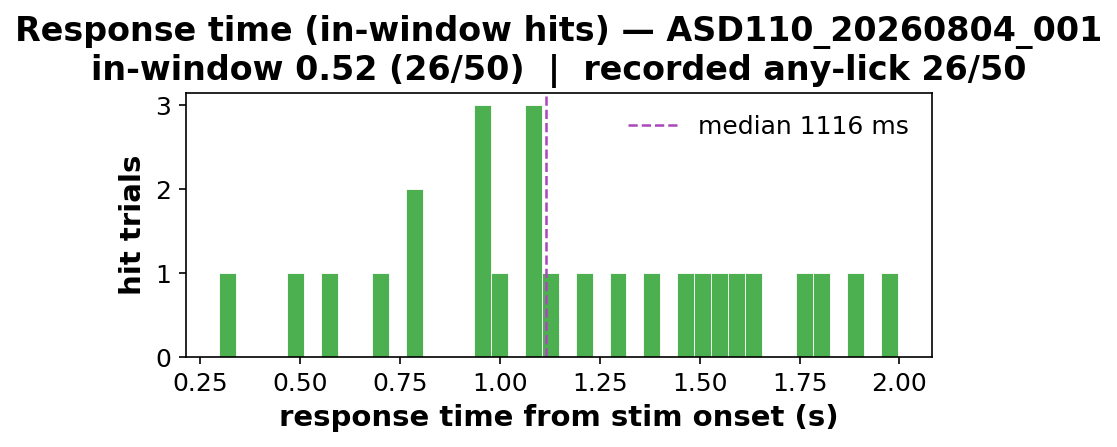

In [5]:
# Response-time histogram. RT = first IN-WINDOW lick (trials.first_lick_t; the engine records it
# only for licks inside the response window, NaN otherwise) measured from the photodiode-corrected
# stim onset (true_onset_t). "in-window hit" = responded in window; compare to the recorded
# trial_outcome, which counts a lick anywhere in the trial.
t = s.trials
rt = t["first_lick_t"] - t["true_onset_t"]           # s from onset; NaN if no in-window lick
rt_hit = rt.dropna().to_numpy()
rec_hit = int((t["trial_outcome"] == "hit").sum())    # recorded (any-lick) hits
n = len(t)

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(rt_hit, bins=40, color="#4caf50", edgecolor="white", linewidth=0.4)
if rt_hit.size:
    ax.axvline(np.median(rt_hit), color="#ab47bc", ls="--", lw=1.2,
               label=f"median {np.median(rt_hit)*1e3:.0f} ms")
    ax.legend(frameon=False)
ax.set_xlabel("response time from stim onset (s)")
ax.set_ylabel("hit trials")
ax.set_title(f"Response time (in-window hits) — {s.session_id}\n"
             f"in-window {rt.notna().mean():.2f} ({rt.notna().sum()}/{n})  |  "
             f"recorded any-lick {rec_hit}/{n}")
fig.tight_layout()
print(f"in-window hits: {rt.notna().sum()}/{n}   recorded any-lick hits: {rec_hit}/{n}")

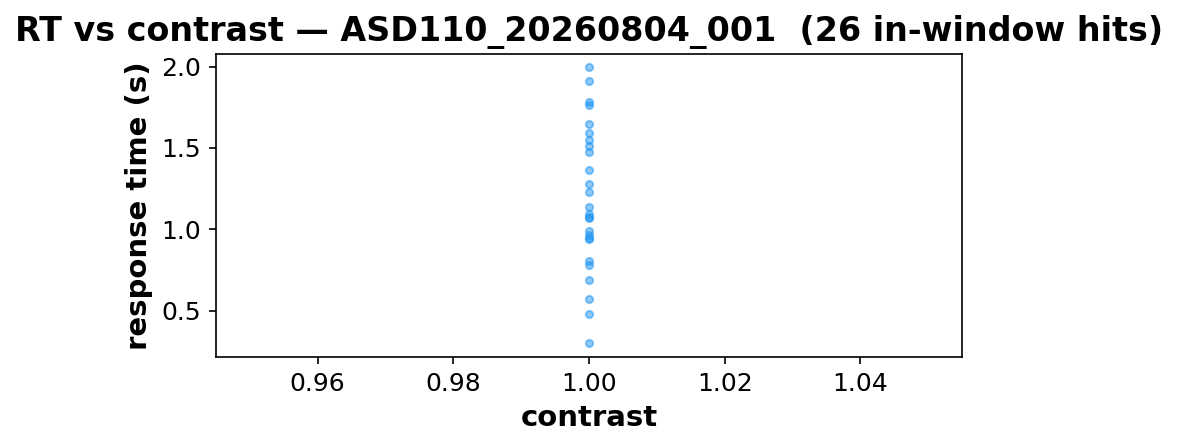

In [6]:
# Response time vs a trial variable — does RT depend on it? COND is any Session.trials column.
COND = "contrast"                                   # or "stim_az_deg"
t = s.trials
rt = t["first_lick_t"] - t["true_onset_t"]
ok = rt.notna()
xv, rv = t[COND][ok].astype(float).to_numpy(), rt[ok].to_numpy()
groups = sorted(np.unique(xv))

fig, ax = plt.subplots(figsize=(6, 3.2))
if 1 < len(groups) <= 12:                           # discrete conditions -> box + median trend
    grouped = [rv[xv == g] for g in groups]
    ax.boxplot(grouped, positions=range(len(groups)), widths=0.5, showfliers=False)
    ax.plot(range(len(groups)), [np.median(d) if len(d) else np.nan for d in grouped],
            "-o", color="#2196f3")
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels([f"{g:g}" for g in groups])
else:                                               # continuous / single value -> scatter
    ax.scatter(xv, rv, s=12, alpha=0.5, color="#2196f3")
ax.set_xlabel(COND); ax.set_ylabel("response time (s)")
ax.set_title(f"RT vs {COND} — {s.session_id}  ({rv.size} in-window hits)")
fig.tight_layout()

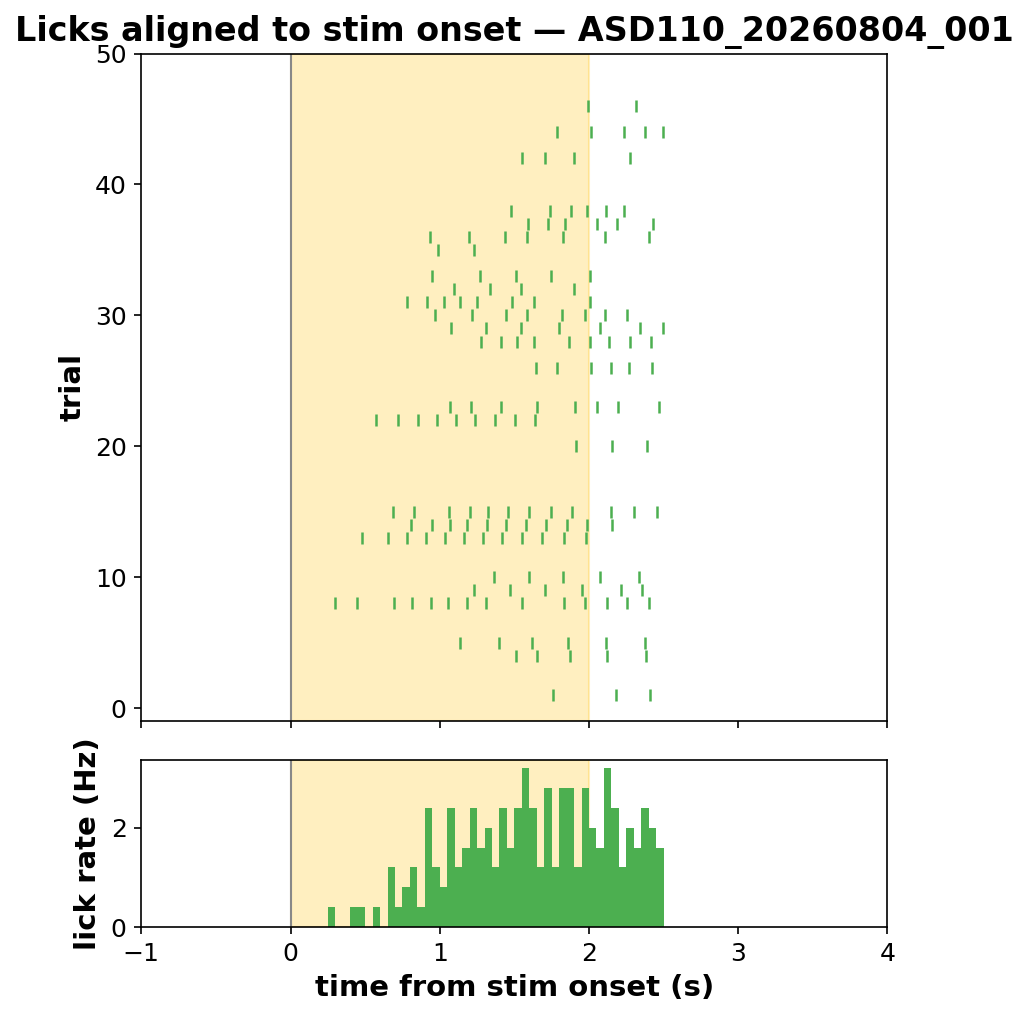

In [7]:
# Lick raster + PSTH aligned to stim onset (0 = onset), straight from the long-form Session.licks
# table: one row per lick, with t_rel_onset_s already = lick time - true_onset_t. Amber band =
# the response window (resp_delay .. resp_delay + response_window), read from task_config.
L = s.licks[s.licks["phase"] == "trial"]             # in-trial licks (exclude ITI licks)
rcfg = s.meta.get("task_config", {}).get("reward", {})
resp_delay = float(rcfg.get("resp_delay_s", rcfg.get("reward_delay_s", 0.6)))
resp_win = float(rcfg.get("response_window", 1.4))

if L.empty:
    print("no licks recorded (lick device not saved) — nothing to raster")
else:
    W = (-1.0, 4.0)                                  # window around onset (s)
    n = s.n_trials
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7), sharex=True,
                                   gridspec_kw={"height_ratios": [4, 1]})
    by_trial = L.groupby("trial_num")["t_rel_onset_s"]
    for pos, tnum in enumerate(s.trials["trial_num"]):
        rel = by_trial.get_group(tnum).to_numpy() if tnum in by_trial.groups else np.array([])
        rel = rel[(rel >= W[0]) & (rel <= W[1])]
        ax1.plot(rel, np.full_like(rel, pos), "|", color="#4caf50", ms=6, mew=1.2)
    for ax in (ax1, ax2):
        ax.axvspan(resp_delay, resp_delay + resp_win, color="#ffc107", alpha=0.25)  # response window
        ax.axvline(0, color="#888", lw=1)                                           # stim onset
    ax1.set_ylabel("trial"); ax1.set_ylim(-1, n)
    ax1.set_title(f"Licks aligned to stim onset — {s.session_id}")
    flat = L["t_rel_onset_s"].to_numpy()
    flat = flat[(flat >= W[0]) & (flat <= W[1])]
    bins = np.arange(W[0], W[1] + 0.05, 0.05)
    rate = np.histogram(flat, bins=bins)[0] / (n * 0.05)
    ax2.bar(bins[:-1], rate, width=0.05, align="edge", color="#4caf50")
    ax2.set_xlabel("time from stim onset (s)"); ax2.set_ylabel("lick rate (Hz)")
    ax2.set_xlim(*W)
    fig.tight_layout()

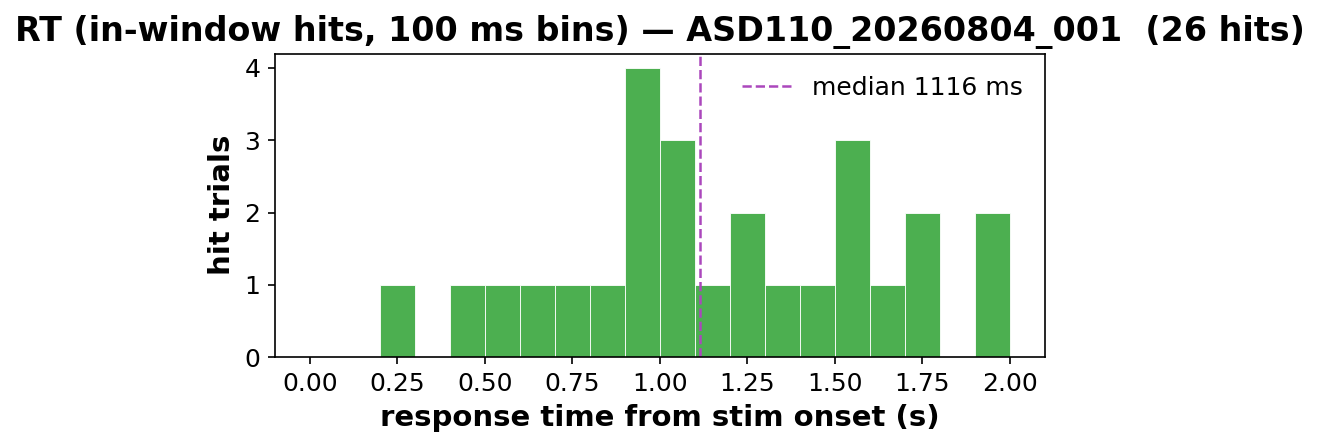

In [8]:
# RT within the response window — in-window hit trials only, fixed 100 ms bins
# (matching the live experiment-UI histogram and the ~1.4 s window).
BIN_S = 0.1
t = s.trials
rt_hit = (t["first_lick_t"] - t["true_onset_t"]).dropna().to_numpy()

fig, ax = plt.subplots(figsize=(6, 3.2))
if rt_hit.size:
    edges = np.arange(0, rt_hit.max() + BIN_S, BIN_S)
    ax.hist(rt_hit, bins=edges, color="#4caf50", edgecolor="white", linewidth=0.4)
    ax.axvline(np.median(rt_hit), color="#ab47bc", ls="--", lw=1.2,
               label=f"median {np.median(rt_hit)*1e3:.0f} ms")
    ax.legend(frameon=False)
else:
    ax.text(0.5, 0.5, "no in-window hits", ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("response time from stim onset (s)")
ax.set_ylabel("hit trials")
ax.set_title(f"RT (in-window hits, {int(BIN_S*1e3)} ms bins) — {s.session_id}  ({rt_hit.size} hits)")
fig.tight_layout()

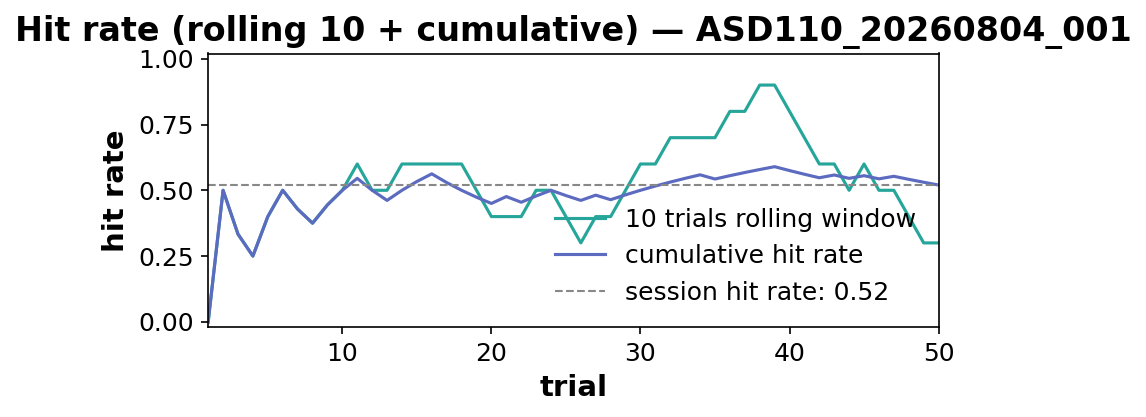

In [9]:
# Rolling + cumulative hit rate. hit = Session.trials.hit (recorded trial_outcome == "hit").
# Rolling = trailing WIN-trial mean; cumulative = running mean (its last point = session hit rate).
WIN = 10
t = s.trials
hit = t["hit"].astype(float).to_numpy()
n = len(hit)
x = np.arange(1, n + 1)
roll = np.array([hit[max(0, i - WIN + 1):i + 1].mean() for i in range(n)])   # trailing rolling mean
cum = np.cumsum(hit) / x                                                     # cumulative mean

fig, ax = plt.subplots(figsize=(6, 3.0))
ax.plot(x, roll, "-", color="#26a69a", lw=1.5, label=f"{WIN} trials rolling window")
ax.plot(x, cum, "-", color="#5c6bc0", lw=1.5, label="cumulative hit rate")
ax.axhline(hit.mean(), color="#888", ls="--", lw=1, label=f"session hit rate: {hit.mean():.2f}")
ax.set_ylim(-0.02, 1.02)
ax.set_xlim(1, max(n, 2))
ax.set_xlabel("trial")
ax.set_ylabel("hit rate")
ax.set_title(f"Hit rate (rolling {WIN} + cumulative) — {s.session_id}")
ax.legend(frameon=False)
fig.tight_layout()
# For a go/nogo task, restrict to GO trials for a true hit rate, e.g.:
#   go = t["stim_az_deg"] < 0                 # go_rule 'left' (az<0 = go); adjust per go_rule
#   hit = (t["hit"] & go)[go].astype(float)   # then roll over go trials

In [10]:
# ── Loading MANY sessions ───────────────────────────────────────────────────────────────────
# Dataset concatenates every session's tables, tagged by session_id. Point it at a directory
# (recursive *.h5), a glob, a list of paths, or Session objects; grow it later with ds.add(...).
subject_dir = data_dir.parents[1]                    # .../ASD110  -> all of this subject's sessions
ds = Dataset(subject_dir)
print(ds)                                            # Dataset(N sessions, M trials)

# Per-session summary in one groupby (rt_ms is a built-in Session.trials column):
ds.trials.groupby("session_id").agg(
    trials=("trial_num", "size"),
    hit_rate=("hit", "mean"),
    median_rt_ms=("rt_ms", "median"),
    reward_uL=("reward_ul", "sum"),
)

Dataset(2 sessions, 100 trials)


,trials,hit_rate,median_rt_ms,reward_uL
session_id,,,,
ASD110_20260803_001,50,0.90,899.090528,0.0
ASD110_20260804_001,50,0.52,1115.377545,400.0
